# 0. Install Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import warnings
warnings.filterwarnings('ignore')

# 1. Data Understanding

In [ ]:
gdown.download(id='1ocGdLsEi82BhQXsXT85A1rCTw23edpL1', output='bakery.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1ocGdLsEi82BhQXsXT85A1rCTw23edpL1
To: /content/bakery.csv
100%|██████████| 1.04M/1.04M [00:00<00:00, 85.1MB/s]


'bakery.csv'

In [ ]:
df = pd.read_csv('bakery.csv')
df.head()

,TransactionNo,Items,DateTime,Daypart,DayType
0,1,Bread,2016-10-30 09:58:11,Morning,Weekend
1,2,Scandinavian,2016-10-30 10:05:34,Morning,Weekend
2,2,Scandinavian,2016-10-30 10:05:34,Morning,Weekend
3,3,Hot chocolate,2016-10-30 10:07:57,Morning,Weekend
4,3,Jam,2016-10-30 10:07:57,Morning,Weekend


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   TransactionNo  20507 non-null  int64 
 1   Items          20507 non-null  object
 2   DateTime       20507 non-null  object
 3   Daypart        20507 non-null  object
 4   DayType        20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


# 2. Data Preperation

## 2.1. Checking Missing Value

In [ ]:
df.isna().sum()

,0
TransactionNo,0
Items,0
DateTime,0
Daypart,0
DayType,0


## 2.2. Checking Duplicate Value

In [ ]:
df.duplicated().sum()

np.int64(1620)

In [ ]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

## 2.3. Change Data Type

In [ ]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18887 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   TransactionNo  18887 non-null  int64         
 1   Items          18887 non-null  object        
 2   DateTime       18887 non-null  datetime64[ns]
 3   Daypart        18887 non-null  object        
 4   DayType        18887 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 885.3+ KB


## 2.4. Feature Engineering

In [ ]:
import calendar

df['Hour'] = df['DateTime'].dt.hour
df['Month'] = pd.to_datetime(df['DateTime']).dt.month
df['Month'] = df['Month'].apply(lambda x: calendar.month_abbr[x])
df['DayOfWeek'] = df['DateTime'].dt.day_name()
df.head()

,TransactionNo,Items,DateTime,Daypart,DayType,Hour,Month,DayOfWeek
0,1,Bread,2016-10-30 09:58:11,Morning,Weekend,9,Oct,Sunday
1,2,Scandinavian,2016-10-30 10:05:34,Morning,Weekend,10,Oct,Sunday
3,3,Hot chocolate,2016-10-30 10:07:57,Morning,Weekend,10,Oct,Sunday
4,3,Jam,2016-10-30 10:07:57,Morning,Weekend,10,Oct,Sunday
5,3,Cookies,2016-10-30 10:07:57,Morning,Weekend,10,Oct,Sunday


# 3. Exploratory Data Analysis

In [ ]:
# Color Palette
palette = sns.color_palette("YlGn", n_colors=10)
palette.reverse()

# order days
order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

## 3.1. Identify Customer Purchasing Behavior Over Time

### 3.1.1. What are the most popular products?

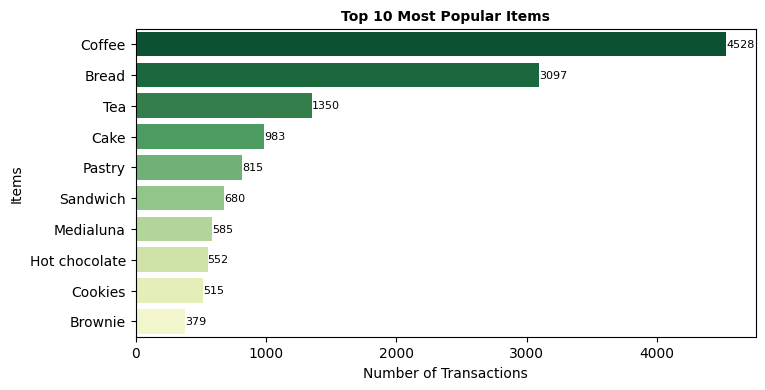

In [ ]:
all_products = df['Items'].value_counts().reset_index()
all_products.columns = ['Items', 'Count']
top_items = all_products.head(10)

# plot
plt.figure(figsize=(8, 4))
sns.barplot(x='Count', y='Items', data=top_items, palette=palette)
plt.title('Top 10 Most Popular Items', fontsize=10, weight='bold')
plt.xlabel('Number of Transactions')
plt.ylabel('Items')

# label
for index, value in enumerate(top_items['Count']):
    plt.text(value + 1, index, str(value), va='center', fontsize=8, color='black')

plt.show()

> Coffee, bread, and tea are the most popular items

### 3.1.2. How do sales vary across different days of the week?

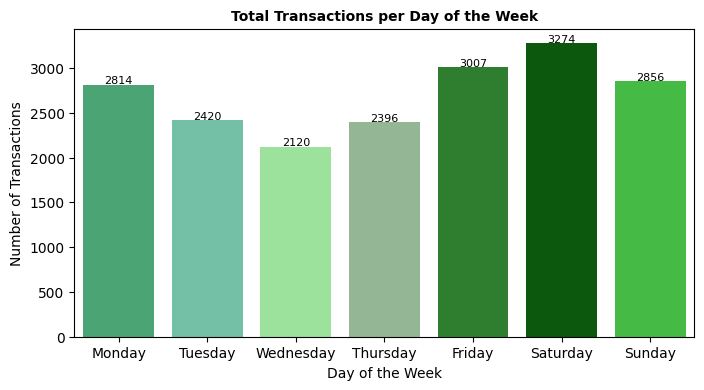

In [ ]:
daily_sales = df['DayOfWeek'].value_counts().reindex(order_days)
palette = ["#3CB371", "#66CDAA", "#90EE90", "#8FBC8F", "#228B22", "#006400", "#32CD32"]

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    x=daily_sales.index,
    y=daily_sales.values,
    palette=palette
)

plt.title('Total Transactions per Day of the Week', fontsize=10, weight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Transactions')

for i, v in enumerate(daily_sales.values):
    plt.text(i, v + 10, str(v), ha='center', fontsize=8, color='black')

plt.show()

> Purchases start the week at moderate levels, decrease to the lowest point on Wednesday, then gradually increase from Thursday, peaking on Saturday before slightly declining on Sunday.

### 3.1.3. How do sales vary throughout the day (hourly)? and what are the peak hours?

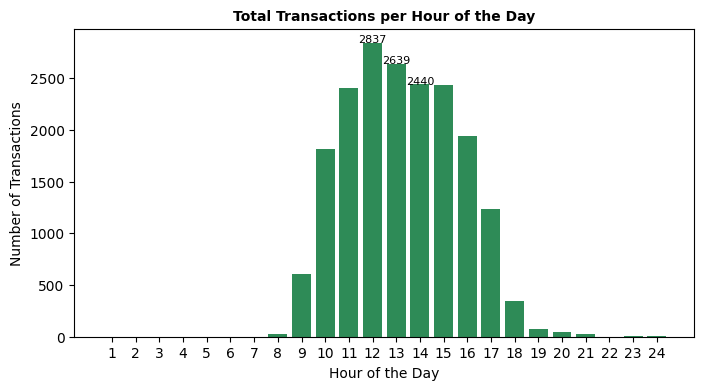

In [ ]:
hourly_sales = df['Hour'].value_counts().sort_index()
hourly_sales = hourly_sales.reindex(range(24), fill_value=0)

plt.figure(figsize=(8,4))
bars = plt.bar(hourly_sales.index + 1, hourly_sales.values, color="seagreen")
plt.title('Total Transactions per Hour of the Day', fontsize=10, fontweight='bold')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Transactions')

top3 = hourly_sales.sort_values(ascending=False).head(3)
for hour, value in top3.items():
    plt.text(hour + 1, value + 5, str(value), ha='center', fontsize=8, color='black')

plt.xticks(range(1, 25))
plt.show()

> Hourly sales trends indicate that purchases usually start at 8 AM, rising steadily until reaching the peak at 12 PM, followed by another high at 1 PM. After this, sales gradually decline until 6 PM, showing that midday is the busiest period for the bakery.

### 3.1.4. What are the most popular items in each time combination?

In [ ]:
time_combine = df.groupby(['Daypart', 'DayType'])['Items'].value_counts().reset_index(name='Count')
daypart_order = ['Morning', 'Afternoon', 'Evening', 'Night']
daytype_order = ['Weekday', 'Weekend']

time_combine['Daypart'] = pd.Categorical(time_combine['Daypart'], categories=daypart_order, ordered=True)
time_combine['DayType'] = pd.Categorical(time_combine['DayType'], categories=daytype_order, ordered=True)
time_combine = time_combine.sort_values(['Daypart', 'DayType', 'Count'], ascending=[True, True, False])

print("\nTop items by Daypart and DayType:")
for (daypart, daytype), group in time_combine.groupby(['Daypart', 'DayType']):
    print(f"\n{daypart} - {daytype}:")
    print(group.head())


Top items by Daypart and DayType:

Morning - Weekday:
     Daypart  DayType      Items  Count
238  Morning  Weekday     Coffee   1402
239  Morning  Weekday      Bread    918
240  Morning  Weekday     Pastry    372
241  Morning  Weekday        Tea    318
242  Morning  Weekday  Medialuna    197

Morning - Weekend:
     Daypart  DayType      Items  Count
304  Morning  Weekend     Coffee    711
305  Morning  Weekend      Bread    572
306  Morning  Weekend     Pastry    200
307  Morning  Weekend  Medialuna    183
308  Morning  Weekend        Tea    123

Afternoon - Weekday:
     Daypart  DayType     Items  Count
0  Afternoon  Weekday    Coffee   1523
1  Afternoon  Weekday     Bread    992
2  Afternoon  Weekday       Tea    562
3  Afternoon  Weekday      Cake    417
4  Afternoon  Weekday  Sandwich    399

Afternoon - Weekend:
      Daypart  DayType     Items  Count
80  Afternoon  Weekend    Coffee    817
81  Afternoon  Weekend     Bread    564
82  Afternoon  Weekend       Tea    302
83  Aft

> In this case, mornings and afternoons on weekdays record the highest transaction volumes, mainly driven by coffee and bread. Weekends also show strong activity during these periods, while evenings and nights across both weekdays and weekends see significantly fewer purchases.

> Unique points observed:
- Coffee, bread, tea, and cake are the dominant items during weekday and weekend afternoons, and they also remain popular in weekday evenings.
- In weekend evenings, purchases shift toward more unusual items such as T-shirt, coffee, “Afternoon with the Baker,” postcards, and bread.
- Morning sales on both weekdays and weekends are consistently led by coffee, bread, pastry, tea, and medialuna.
- Nighttime sales are very limited, with niche items dominating: Valentine’s card, juice, and mineral water on weekdays, while vegan feast, hot chocolate, and Scandinavian bread appear on weekends.

### 3.1.5. How do purchases vary across months for each year?

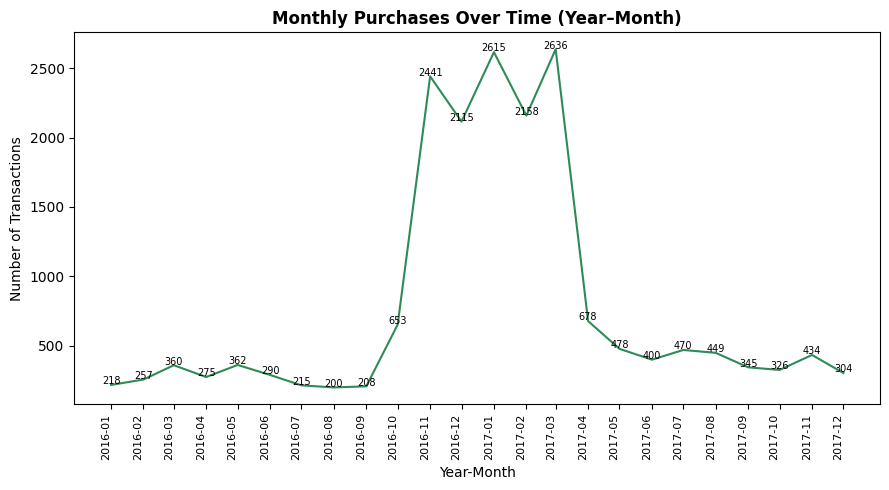

In [ ]:
df['YearMonth'] = df['DateTime'].dt.to_period('M').astype(str)

monthly_sales = df.groupby('YearMonth').size().reset_index(name='Transactions')
monthly_sales['YearMonth'] = pd.to_datetime(monthly_sales['YearMonth'])
monthly_sales = monthly_sales.sort_values('YearMonth')

plt.figure(figsize=(9, 5))
plt.plot(monthly_sales['YearMonth'], monthly_sales['Transactions'], color="seagreen")
plt.title('Monthly Purchases Over Time (Year–Month)', fontsize=12, fontweight="bold")
plt.xlabel('Year-Month')
plt.ylabel('Number of Transactions')

plt.xticks(
    ticks=monthly_sales['YearMonth'],
    labels=monthly_sales['YearMonth'].dt.strftime('%Y-%m'),
    rotation=90,
    ha='right',
    fontsize=8
)

for x, y in zip(monthly_sales['YearMonth'], monthly_sales['Transactions']):
    plt.text(x, y + 5, str(y), ha='center', fontsize=7)

plt.tight_layout()
plt.show()

> dari tahun 2016 purchases flutatif hingga bulan september, baru mengalami kenaikan di 2016-10 drastis di blan november hingga 2017 april setelah itu turun drastis april 2017 dan standasr flutatus lagi kayak di tahun 2016, jadi lonjakan besarnya di rentang 2016-11 hingga 2017-03

### 3.1.6. Which items were purchased the most during the peak demand period (Nov 2016 - Mar 2017)?

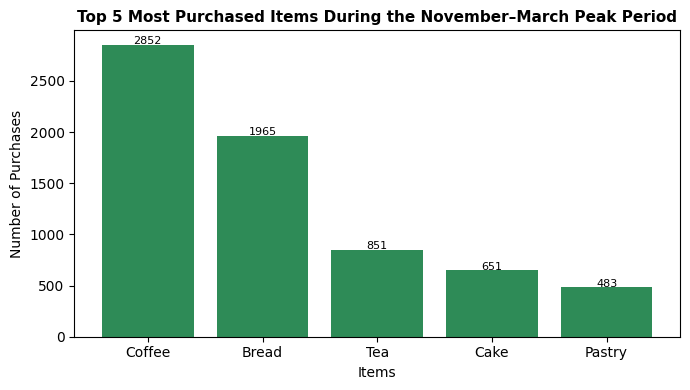

In [ ]:
from collections import Counter

start = '2016-11-01'
end = '2017-03-31'
df_period = df[(df['DateTime'] >= start) & (df['DateTime'] <= end)]

all_items = df_period['Items'].str.split(',').sum()
item_counts = Counter(all_items).most_common(5)
items = [i[0] for i in item_counts]
counts = [i[1] for i in item_counts]

plt.figure(figsize=(7, 4))
plt.bar(items, counts,  color="seagreen")
plt.title("Top 5 Most Purchased Items During the November–March Peak Period", fontsize=11, fontweight="bold")
plt.xlabel("Items")
plt.ylabel("Number of Purchases")

for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

> Daily transaction trends show fluctuations throughout the year. However, more extreme swings are observed between late 2016 and April 2017, suggesting some unusual variations in customer demand during that period.

# 4. Data Modeling (Market Basket Analysis) using Apriori Algorithm

## 4.1. Basket

In [ ]:
basket = df.groupby('TransactionNo')['Items'].apply(list).to_list()
basket[:5]

[['Bread'],
 ['Scandinavian'],
 ['Hot chocolate', 'Jam', 'Cookies'],
 ['Muffin'],
 ['Coffee', 'Pastry', 'Bread']]

In [ ]:
TE = TransactionEncoder()
TE_array = TE.fit(basket).transform(basket)
df = pd.DataFrame(TE_array, columns=TE.columns_)
df.head()

,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 4.2. Frequents

In [ ]:
frequents = apriori(df, min_support=0.01, use_colnames=True)
frequents.sort_values('support', ascending=False)

,support,itemsets
6,0.478394,(Coffee)
2,0.327205,(Bread)
26,0.142631,(Tea)
4,0.103856,(Cake)
34,0.090016,"(Coffee, Bread)"
...,...,...
11,0.010565,(Hearty & Seasonal)
20,0.010460,(Salad)
30,0.010354,"(Alfajores, Bread)"
58,0.010037,"(Coffee, Bread, Cake)"


- `Fungsi apriori`: mencari kombinasi item (itemsets) yang sering muncul bersama di transaksi.
- `min_support=0.01`: artinya kita hanya ambil item/kombinasi item yang muncul minimal 1% dari total transaksi. Jadi item yang terlalu jarang muncul akan diabaikan.
- `use_colnames=True`: supaya hasil itemsets ditampilkan dengan nama barang asli (misalnya "Coffee", "Bread") bukan index angka.

- `support`: seberapa sering item/kombinasi item itu muncul.
- `itemsets`: kombinasi barang yang ditemukan.
- Hasil itemsets tadi diurutkan berdasarkan nilai support (frekuensi kemunculan) dari yang paling sering muncul ke yang paling jarang.

## 4.3. Association Rules

In [ ]:
rules = association_rules(frequents, metric='lift', min_threshold=1)
rules.sort_values('lift', ascending=False).head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
38,"(Coffee, Tea)",(Cake),0.049868,0.103856,0.010037,0.201271,1.937977,1.0,0.004858,1.121962,0.509401,0.069853,0.108705,0.148957
41,(Cake),"(Coffee, Tea)",0.103856,0.049868,0.010037,0.096643,1.937977,1.0,0.004858,1.051779,0.540090,0.069853,0.049230,0.148957
9,(Cake),(Hot chocolate),0.103856,0.058320,0.011410,0.109868,1.883874,1.0,0.005354,1.057910,0.523553,0.075683,0.054740,0.152760
8,(Hot chocolate),(Cake),0.058320,0.103856,0.011410,0.195652,1.883874,1.0,0.005354,1.114125,0.498236,0.075683,0.102434,0.152760
10,(Tea),(Cake),0.142631,0.103856,0.023772,0.166667,1.604781,1.0,0.008959,1.075372,0.439556,0.106736,0.070090,0.197779


Dari hasil apriori,  dobikin aturan asosiasi.
- `metric='lift'`: pakai ukuran lift buat saring aturan.
- `min_threshold=1`: cuma ambil aturan yang lift ≥ 1 (artinya hubungan item itu lebih kuat daripada kebetulan).

Metrik
- `antecedents`: Barang awal atau kalau orang beli barang ini
- `consequents`: Barang yang mengikuti atau  kemungkinan juga beli barang ini
- `antecedent support`: Seberapa sering barang awal muncul di semua transaksi
- `consequent support`: Seberapa sering barang target muncul di semua transaksi
- `support`: Seberapa sering keduanya muncul bareng
- `confidence`: Kemungkinan orang beli B jika sudah beli A
- `lift`: Seberapa kuat hubungannya dibanding kebetulan (lift > 1 = ada hubungan kuat)
- `representativity`: Apakah aturan ini cukup mewakili keseluruhan data (mirip stabilitas aturan)
- `leverage`: Bedanya antara kenyataan vs kebetulan (semakin tinggi, semakin berarti)
- `conviction`: Ukur “ketergantungan”, kalau beli A, seberapa jarang A terjadi tanpa B   
- `zhangs_metric`:Ukuran fairness,  biar ga terlalu berat sebelah ke salah satu barang
- `jaccard`: Seberapa besar tumpang tindih A & B dibanding total gabungan
- `certainty`: Keyakinan seberapa konsisten aturan ini benar
- `kulczynski`: Rata-rata dari confidence A→B dan B→A (jadi lebih balance)

In [ ]:
rules[['antecedents','consequents','support','confidence','lift']].sort_values(by=['lift'],ascending= False).head(12)

,antecedents,consequents,support,confidence,lift
38,"(Coffee, Tea)",(Cake),0.010037,0.201271,1.937977
41,(Cake),"(Coffee, Tea)",0.010037,0.096643,1.937977
9,(Cake),(Hot chocolate),0.011410,0.109868,1.883874
8,(Hot chocolate),(Cake),0.011410,0.195652,1.883874
10,(Tea),(Cake),0.023772,0.166667,1.604781
11,(Cake),(Tea),0.023772,0.228891,1.604781
31,(Toast),(Coffee),0.023666,0.704403,1.472431
30,(Coffee),(Toast),0.023666,0.049470,1.472431
36,"(Coffee, Bread)",(Pastry),0.011199,0.124413,1.444872
37,(Pastry),"(Coffee, Bread)",0.011199,0.130061,1.444872


In [ ]:
rules[['antecedents','consequents','support','confidence','lift']].sort_values(by=['confidence'],ascending= False).head(5)

,antecedents,consequents,support,confidence,lift
31,(Toast),(Coffee),0.023666,0.704403,1.472431
29,(Spanish Brunch),(Coffee),0.010882,0.598837,1.251766
19,(Medialuna),(Coffee),0.035182,0.569231,1.189878
23,(Pastry),(Coffee),0.047544,0.552147,1.154168
0,(Alfajores),(Coffee),0.019651,0.540698,1.130235


**Top Based on Lift**
- `Tea + Coffee` -> `Cake` (Lift: 1.94, Confidence: 20%) → Saat pelanggan membeli Tea dan Coffee, mereka cenderung juga membeli Cake.
- `Hot Chocolate` -> `Cake` (Lift: 1.88, Confidence: 19%) → Ada hubungan kuat dua arah antara Hot Chocolate dan Cake.
- `Tea` -> `Cake` (Lift: 1.60, Confidence: 16–22%) → Pelanggan Tea sering menambahkan Cake, dan sebaliknya.
- `Toast` -> `Coffee` (Lift: 1.47, Confidence: 70%) → Sebagian besar pembeli Toast juga membeli Coffee.
- `Coffee + Bread`-> `Pastry` (Lift: 1.44, Confidence: 12%) → Kombinasi Coffee dan Bread sering diikuti dengan Pastry.
- `Sandwich` -> `Tea` (Lift: 1.40, Confidence: 10–20%) → Terdapat kecenderungan pelanggan mengombinasikan Sandwich dengan Tea.

**Top Based on Confidence**
- `Toast` -> `Coffee` (Lift: 1.47, Confidence: 70%) → Toast sering dipasangkan dengan Coffee.
- `Spanish Brunch` > `Coffee` (Lift: 1.25, Confidence: 60%) → Hampir semua pembeli Spanish Brunch juga membeli Coffee.
- `Medialuna` -> `Coffee` (Lift: 1.18, Confidence: 57%) → Medialuna biasanya dibeli bersama Coffee.
- `Pastry` -> `Coffee` (Lift: 1.15, Confidence: 55%) → Sebagian besar pembeli Pastry juga membeli Coffee.
- `Alfajores` -> `Coffee` (Lift: 1.13, Confidence: 54%) → Alfajores sering dipasangkan dengan Coffee.




# 5. Business Insight

- Top Products: Coffee, bread and tea.
- Purchases dip midweek (Wednesday) and peak on Saturdays.
- Midday (1-2 PM) is the busiest period.
- Time-of-Day Preferences:
  - Weekday mornings/afternoons: Coffee, bread, Tea.
  - Weekend mornings/afternoons: Similar items remain popular.
  - Evenings/nights: Fewer transactions, niche items dominate.
- Peak demand occurs November 2016 - March 2017, accounting for over 50% of total transactions.
- Market Basket Insights:
  - Tea, Coffee, and Hot Chocolate are often purchased with Cake.
  - Coffee naturally pairs with light meals like Bread, Pastry, and Toast.
  - Sandwiches are commonly bought with Tea.
  - Toast, Spanish Brunch, Medialuna, Pastry, and Alfajores are frequently bought with Coffee.
  - Coffee acts as an anchor product and key driver for upselling and combo offers.

# 6. Business Recommendations

1. Product Bundling
- Afternoon Bundle (Tea + Coffee + Cake): Popular in afternoon, fits natural customer habits.
- Sweet Combo (Hot Chocolate + Cake): Strong comfort pairing.
- Tea Time Duo (Tea + Cake): Light option for afternoon snacks.
- Breakfast Bundle (Coffee + Toast): Matches morning rush demand.
- Morning Trio (Coffee + Bread + Pastry): Quick and filling for early customers.

2. Cross-Selling
- When customers buy Pastry, Cake, Cookies, Medialuna, or Sandwich → suggest Coffee.
- When customers buy Toast or Sandwich → suggest Tea or Coffee.
- When customers buy Tea or Coffee together → suggest Cake.

3. Store Layout
- Position Coffee as the anchor in center.
- Place Cake near Tea, Coffee, and Hot Chocolate.
- Keep Toast, Sandwich, and Pastry close to Coffee/Tea.
- Niche/seasonal items (T-shirt, postcards, vegan feast) in a small separate corner.

4. Timing Strategy
- Peak hours at 12 to 1 PM and Saturday mornings focus staff and ready-made bundles for speed
- Weekday mornings and afternoons highlight Breakfast Bundle, Morning Trio, and Afternoon Bundle
- Weekend mornings and afternoons promote Afternoon Bundle and Sweet Combo
- Evenings and nights stock only niche products and slow movers with a limited menu
- Monthly trends call for extra promotions in January to March and November to December when overall sales are high

5. Additional Strategies
- Top-selling items Coffee, Bread, Tea, and Cake should be kept fully stocked at all times
- Midday promotions offer bundle discounts around 12 to 1 PM when transactions peak
- Weekday recovery strategy implements Thursday and Friday upsell campaigns before the weekend

In [ ]:
df.to_csv('bakery.csv', index=False)